# Hybrid Power-to-X Plant with Sector Coupling

This model builds on `01_solar_to_market.ipynb` by connecting **electricity, hydrogen, and heat**
into a single site. Instead of a plant that only sells to the market, we now have a plant that
also *consumes* its own renewable power to produce hydrogen and district heat, and only trades
the leftover with the outside world.

The objective is to model a **30 MW Solar PV + 50 MW Wind** hybrid plant with a grid connection,
a **5 MW electrolyzer** producing hydrogen for a fixed offtake contract, and a **heat pump**
covering a fixed district heating demand. Waste heat captured from the electrolyzer is injected
into the same heat network. A battery and a thermal store help shift energy in time, and any
surplus heat can be sold to an external district heating (DH) grid.

## 🛠️ System Topology
1. **Buses:** `electricity`, `hydrogen`, `heat` — three energy carriers, one node each.
2. **Generators (Source):** Solar PV (30 MW) and Wind (50 MW), both bounded by DK1 weather profiles.
3. **Generators (Grid):** Two generators represent the grid connection — `Grid_Import` (buys at the
   DK1 spot price) and `Grid_Export` (sells surplus RE at the DK1 spot price, modeled the same way
   as the sink in Model 01).
4. **Loads:** A constant hydrogen offtake demand and a seasonal (winter-high) district heating demand.
5. **Links (conversion):**
   - `Electrolyzer` — 5 MW, electricity → hydrogen (main product) + heat (captured by-product), both
     outputs on the same link.
   - `Heat_Pump` — electricity → heat, at a fixed COP.
6. **Storage:** A `Battery` (StorageUnit) buffers electricity; a `Thermal_Storage` (Store) buffers heat.
7. **Generator (Heat sink):** `Heat_Market` — sells any heat surplus (beyond demand and storage) to
   an external DH grid at a fixed price, modeled as a negative-cost sink exactly like `Grid_Export`
   in Model 01.

Because solar and wind have (near) zero marginal cost while grid import is priced at the DK1 spot
price, the cost-minimizing solver will **always prefer to run the electrolyzer and heat pump on
renewable power first**, and only fall back to grid import when RE is insufficient. No extra
constraint is needed for this — it falls directly out of the merit order.

<img src="../assets/model_2.jpg" alt="Model 02 System Topology" width="800">


In [21]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

# Import custom publication-quality plotting style
sys.path.append('../')
from utils.viz_utils import set_nature_style

# Activate global styling
set_nature_style()

# Load processed data
df_solar = pd.read_csv('../data/processed/pv_2025_hourly.csv', index_col='time', parse_dates=True)
df_wind = pd.read_csv('../data/processed/wind_2025_hourly.csv', index_col='time', parse_dates=True)
df_price = pd.read_csv('../data/processed/electricity_price_2025_hourly.csv', index_col='time', parse_dates=True)

# This completely eliminates any duplicate timestamps caused by Daylight Saving Time.
perfect_index = pd.date_range(start='2025-01-01 00:00', end='2025-12-31 23:00', freq='1h')

# Force all dataframes to use this clean index
df_solar.index = perfect_index
df_wind.index = perfect_index
df_price.index = perfect_index

# Capacity factors, clipped to [0, 1] as a safety margin against noisy raw data
df_solar['capacity_factor'] = df_solar['pv_generation_kw'].clip(upper=1.0)
df_wind['capacity_factor'] = df_wind['wind_generation_kw'].clip(upper=1.0)


Nature plotting style applied globally!


## ⚙️ Technical Parameters

As in Model 01, all technical and economic assumptions live in a single dictionary. This keeps the
network-building code free of "magic numbers" and makes it easy to re-run the notebook for a
sensitivity analysis (e.g. a smaller electrolyzer, or a cheaper heat pump) by only touching this cell.

**Assumptions worth flagging** (adjust freely to match your own project):
- **Hydrogen offtake:** a constant 1.5 MW (LHV-basis) demand, representing a fixed industrial
  contract that is smaller than the electrolyzer's peak output (so the plant can lean on renewables
  most hours and only rarely needs the grid to cover the contract).
- **Heat demand:** no district heating data file was provided for this model, so a simple seasonal
  sine curve (winter-high, summer-low) is generated directly in code instead of read from a CSV.
- **Investment costs** below are indicative, order-of-magnitude figures (not sourced from a specific
  project) — replace them with your own quotes for a real techno-economic study.


In [22]:
# Centralized dictionary for technical and economic parameters
DISCOUNT_RATE = 0.04

def annuity(lifetime_years, investment, fom_percent):
    # Annualize an overnight investment using the Capital Recovery Factor (CRF),
    # then add fixed O&M (as a % of investment) on top.
    r = DISCOUNT_RATE
    crf = (r * (1 + r) ** lifetime_years) / ((1 + r) ** lifetime_years - 1)
    return investment * (crf + fom_percent / 100.0)

tech_param = {
    'solar_pv': {
        'p_nom': 30.0,                                   # Nominal capacity, MW
        'capital_cost': annuity(30, 550_000, 2.0),       # EUR/MW/year
        'marginal_cost': 0.0                              # EUR/MWh
    },
    'wind': {
        'p_nom': 50.0,
        'capital_cost': annuity(25, 1_100_000, 2.5),
        'marginal_cost': 1.5
    },
    'grid_connection': {
        'p_nom': 60.0,                                   # Physical cable limit, MW
        'grid_tariff': 8.0                                # EUR/MWh added on top of spot when importing
    },
    'electrolyzer': {
        'p_nom': 5.0,                                    # MW electrical input
        'capital_cost': annuity(20, 900_000, 4.0),
        'marginal_cost': 0.0,
        'efficiency_h2': 0.65,                            # Electricity -> H2 (LHV basis)
        'efficiency_heat': 0.20                           # Electricity -> captured heat (by-product)
    },
    'heat_pump': {
        'p_nom': 4.0,                                     # MW electrical input
        'capital_cost': annuity(20, 500_000, 1.5),
        'marginal_cost': 0.5,
        'cop': 3.5                                        # Fixed coefficient of performance
    },
    'battery': {
        'p_nom': 5.0,                                     # MW
        'max_hours': 2.0,                                 # hours -> 10 MWh
        'capital_cost': annuity(15, 280_000 * 2, 1.5),     # EUR/MW/year (sized on power * duration)
        'efficiency_store': 0.95,
        'efficiency_dispatch': 0.95
    },
    'thermal_storage': {
        'e_nom': 20.0,                                    # MWh
        'capital_cost': annuity(25, 40_000, 1.0),          # EUR/MWh/year
        'standing_loss': 0.01                              # hourly self-discharge
    }
}

prices = {
    'h2_demand_mw': 1.5,          # Constant hydrogen offtake, MW (LHV basis)
    'h2_lhv_kwh_per_kg': 33.33,   # kWh/kg, used later to convert MWh -> kg H2
    'dh_sale_price': 30.0,        # EUR/MWh, price for surplus heat sold to the external DH grid
    'heat_demand_avg_mw': 3.0,    # Average district heating demand, MW
    'heat_demand_amplitude_mw': 2.0  # Seasonal swing around the average
}

print("✓ Technical and economic parameters loaded")


✓ Technical and economic parameters loaded


## 🏗️ Initializing the Network

This system couples three energy carriers, so instead of a single bus we now need three: one for
electricity, one for hydrogen, and one for heat. Every component below is attached to exactly one
(or more, in the case of multi-output links) of these buses.


In [23]:
# Initialize a new PyPSA network
n = pypsa.Network()
n.set_snapshots(df_solar.index)

# Add the three energy-carrier buses
n.add("Bus", "electricity")
n.add("Bus", "hydrogen")
n.add("Bus", "heat")


Index(['heat'], dtype='object')

## ⚡ Generators and Grid Connection

Solar and wind are added exactly as in Model 01, each bounded by its own weather-driven capacity
factor. The grid connection is again split into two generators — one for buying, one for selling —
so that each direction can carry its own price:

- `Grid_Import` buys at the DK1 spot price plus a fixed grid tariff.
- `Grid_Export` sells surplus renewable power at the DK1 spot price (revenue = negative cost, same
  trick as `Grid_Export` in Model 01).

Because `Grid_Import` is always more expensive per MWh than solar or wind (marginal cost ≈ 0), the
solver will draw on renewables first whenever they're available — which is exactly the "RE-first"
behavior we want for the electrolyzer and heat pump downstream.


In [24]:
# 1. Solar PV generator
n.add("Generator",
      "Solar_PV",
      bus="electricity",
      p_nom=tech_param['solar_pv']['p_nom'],
      p_max_pu=df_solar['capacity_factor'],
      capital_cost=tech_param['solar_pv']['capital_cost'],
      marginal_cost=tech_param['solar_pv']['marginal_cost'])

# 2. Wind generator
n.add("Generator",
      "Wind",
      bus="electricity",
      p_nom=tech_param['wind']['p_nom'],
      p_max_pu=df_wind['capacity_factor'],
      capital_cost=tech_param['wind']['capital_cost'],
      marginal_cost=tech_param['wind']['marginal_cost'])

# 3. Grid import (buying)
n.add("Generator",
      "Grid_Import",
      bus="electricity",
      p_nom=tech_param['grid_connection']['p_nom'],
      marginal_cost=df_price['price'] + tech_param['grid_connection']['grid_tariff'])

# 4. Grid export (selling surplus RE) - negative generator, same pattern as Model 01
n.add("Generator",
      "Grid_Export",
      bus="electricity",
      p_nom=tech_param['grid_connection']['p_nom'],
      p_min_pu=-1.0,
      p_max_pu=0.0,
      marginal_cost=-df_price['price'])


Index(['Grid_Export'], dtype='object')

## 🎯 Demands

The hydrogen offtake is modeled as a flat `Load` — a fixed industrial contract that must be met in
every hour, regardless of how sunny or windy it is. The district heating demand is modeled as a
simple seasonal sine curve (higher in winter, lower in summer), since no DH demand data file was
supplied for this model.


In [25]:
# Constant hydrogen offtake demand
h2_demand = pd.Series(prices['h2_demand_mw'], index=n.snapshots)

# Seasonal (winter-high) district heating demand - simple sine curve, no data file needed
day_of_year = n.snapshots.dayofyear
heat_demand = prices['heat_demand_avg_mw'] - prices['heat_demand_amplitude_mw'] * np.sin(
    (day_of_year - 80) * 2 * np.pi / 365
)
heat_demand = pd.Series(np.clip(heat_demand, 0.2, None), index=n.snapshots)

n.add("Load", "H2_Demand", bus="hydrogen", p_set=h2_demand)
n.add("Load", "Heat_Demand", bus="heat", p_set=heat_demand)

print(f"Average hydrogen demand: {h2_demand.mean():.2f} MW")
print(f"Average heat demand: {heat_demand.mean():.2f} MW (min {heat_demand.min():.2f}, max {heat_demand.max():.2f})")


Average hydrogen demand: 1.50 MW
Average heat demand: 3.00 MW (min 1.00, max 5.00)


## 🔗 Conversion Links: Electrolyzer and Heat Pump

Both conversion assets draw from the shared `electricity` bus, which is exactly what makes the
"renewables-first" behavior work automatically: solar and wind are the cheapest electrons available,
so the solver uses them for hydrogen and heat production before reaching for (more expensive)
grid imports.

- **Electrolyzer:** a `Link` with *two* outputs — `bus1` (hydrogen, the main product) and `bus2`
  (heat, the captured by-product), each with its own efficiency (`efficiency` and `efficiency2`).
- **Heat Pump:** a simple single-output `Link` — electricity in, heat out, scaled by a fixed COP.


In [26]:
# Electrolyzer: electricity -> hydrogen (main) + heat (captured by-product)
n.add("Link",
      "Electrolyzer",
      bus0="electricity",
      bus1="hydrogen",
      bus2="heat",
      p_nom=tech_param['electrolyzer']['p_nom'],
      efficiency=tech_param['electrolyzer']['efficiency_h2'],
      efficiency2=tech_param['electrolyzer']['efficiency_heat'],
      capital_cost=tech_param['electrolyzer']['capital_cost'],
      marginal_cost=tech_param['electrolyzer']['marginal_cost'])

# Heat Pump: electricity -> heat, scaled by a fixed COP
n.add("Link",
      "Heat_Pump",
      bus0="electricity",
      bus1="heat",
      p_nom=tech_param['heat_pump']['p_nom'],
      efficiency=tech_param['heat_pump']['cop'],
      capital_cost=tech_param['heat_pump']['capital_cost'],
      marginal_cost=tech_param['heat_pump']['marginal_cost'])


Index(['Heat_Pump'], dtype='object')

## 🔋 Storage: Battery and Thermal Store

Two storage components help the plant shift energy in time instead of relying purely on
instantaneous matching:

- **`Battery`** (`StorageUnit`) — power-limited (`p_nom`) with a fixed duration (`max_hours`),
  buffering electricity so more RE can be captured and used later by the electrolyzer or heat pump
  instead of being curtailed or exported at a low price.
- **`Thermal_Storage`** (`Store`) — energy-limited (`e_nom`), buffering heat between the
  electrolyzer/heat pump and the heat demand, smoothing out the mismatch between when heat is
  produced and when it's needed.

Both are set to `cyclic`, meaning the state of charge must return to its starting level by the end
of the year — a standard assumption so the year-long optimization doesn't simply "drain" storage for
a one-off gain.


In [27]:
# Battery (StorageUnit) - power-limited electricity buffer
n.add("StorageUnit",
      "Battery",
      bus="electricity",
      p_nom=tech_param['battery']['p_nom'],
      max_hours=tech_param['battery']['max_hours'],
      capital_cost=tech_param['battery']['capital_cost'],
      efficiency_store=tech_param['battery']['efficiency_store'],
      efficiency_dispatch=tech_param['battery']['efficiency_dispatch'],
      cyclic_state_of_charge=True)

# Thermal Storage (Store) - energy-limited heat buffer
n.add("Store",
      "Thermal_Storage",
      bus="heat",
      e_nom=tech_param['thermal_storage']['e_nom'],
      e_cyclic=True,
      capital_cost=tech_param['thermal_storage']['capital_cost'],
      standing_loss=tech_param['thermal_storage']['standing_loss'])


Index(['Thermal_Storage'], dtype='object')

## 🌡️ Selling Surplus Heat

Once storage is full and demand is met, any additional heat (mostly captured from the electrolyzer
on sunny/windy hours) still needs somewhere to go. `Heat_Market` is a negative generator — the same
sink pattern used for `Grid_Export` — that sells surplus heat to an external district heating grid
at a fixed price, so the solver has an economic incentive to make use of that heat instead of simply
having no outlet for it.


In [28]:
n.add("Generator",
      "Heat_Market",
      bus="heat",
      p_nom=50.0,
      p_min_pu=-1.0,
      p_max_pu=0.0,
      marginal_cost=-prices['dh_sale_price'])


Index(['Heat_Market'], dtype='object')

## 🧠 Running the Optimization

With buses, generators, loads, links, and storage all defined, the network is passed to the HiGHS
solver, which finds the least-cost (highest-revenue) dispatch across all 8760 hours simultaneously.

Note: since every asset here has a **fixed** size (`p_nom_extendable=False` everywhere, the default),
PyPSA's solved `n.objective` only reflects the *dispatch* decisions — OPEX minus market revenue. It
does **not** include CAPEX, because capacity isn't a decision variable in this run. We add CAPEX back
in ourselves in the economic evaluation section below.


In [29]:
# Optimize the network dispatch using the HiGHS solver
status, condition = n.optimize(solver_name='highs')

print(f"Solver Status: {status} ({condition})")
print(f"Total Objective Value (Net Annual OPEX, i.e. OPEX minus market revenue): €{n.objective:,.2f}")


Index(['Thermal_Storage'], dtype='object', name='Store')
Index(['Electrolyzer', 'Heat_Pump'], dtype='object', name='Link')
Index(['electricity', 'hydrogen', 'heat'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 17.01it/s]
INFO:linopy.io: Writing time: 2.61s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 105120 primals, 236520 duals
Objective: -7.73e+04
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUn

Solver Status: ok (optimal)
Total Objective Value (Net Annual OPEX, i.e. OPEX minus market revenue): €-77,283.52


## 📊 Analyzing the Results

We first check the RE-first hypothesis directly — how much of the electrolyzer's and heat pump's
electricity input actually came from solar/wind versus the grid — then look at the overall annual
generation mix and the two storage state-of-charge profiles.


Total Solar Production:      17,884 MWh
Total Wind Production:       17,854 MWh
Total Grid Import:           4,859 MWh
Total Grid Export:           13,603 MWh
---------------------------------------------
Total Hydrogen Produced:     13,140 MWh (394,239 kg)
Heat Captured (Electrolyzer):4,043 MWh
Heat Produced (Heat Pump):   22,541 MWh
Surplus Heat Sold to DH Grid:-0 MWh


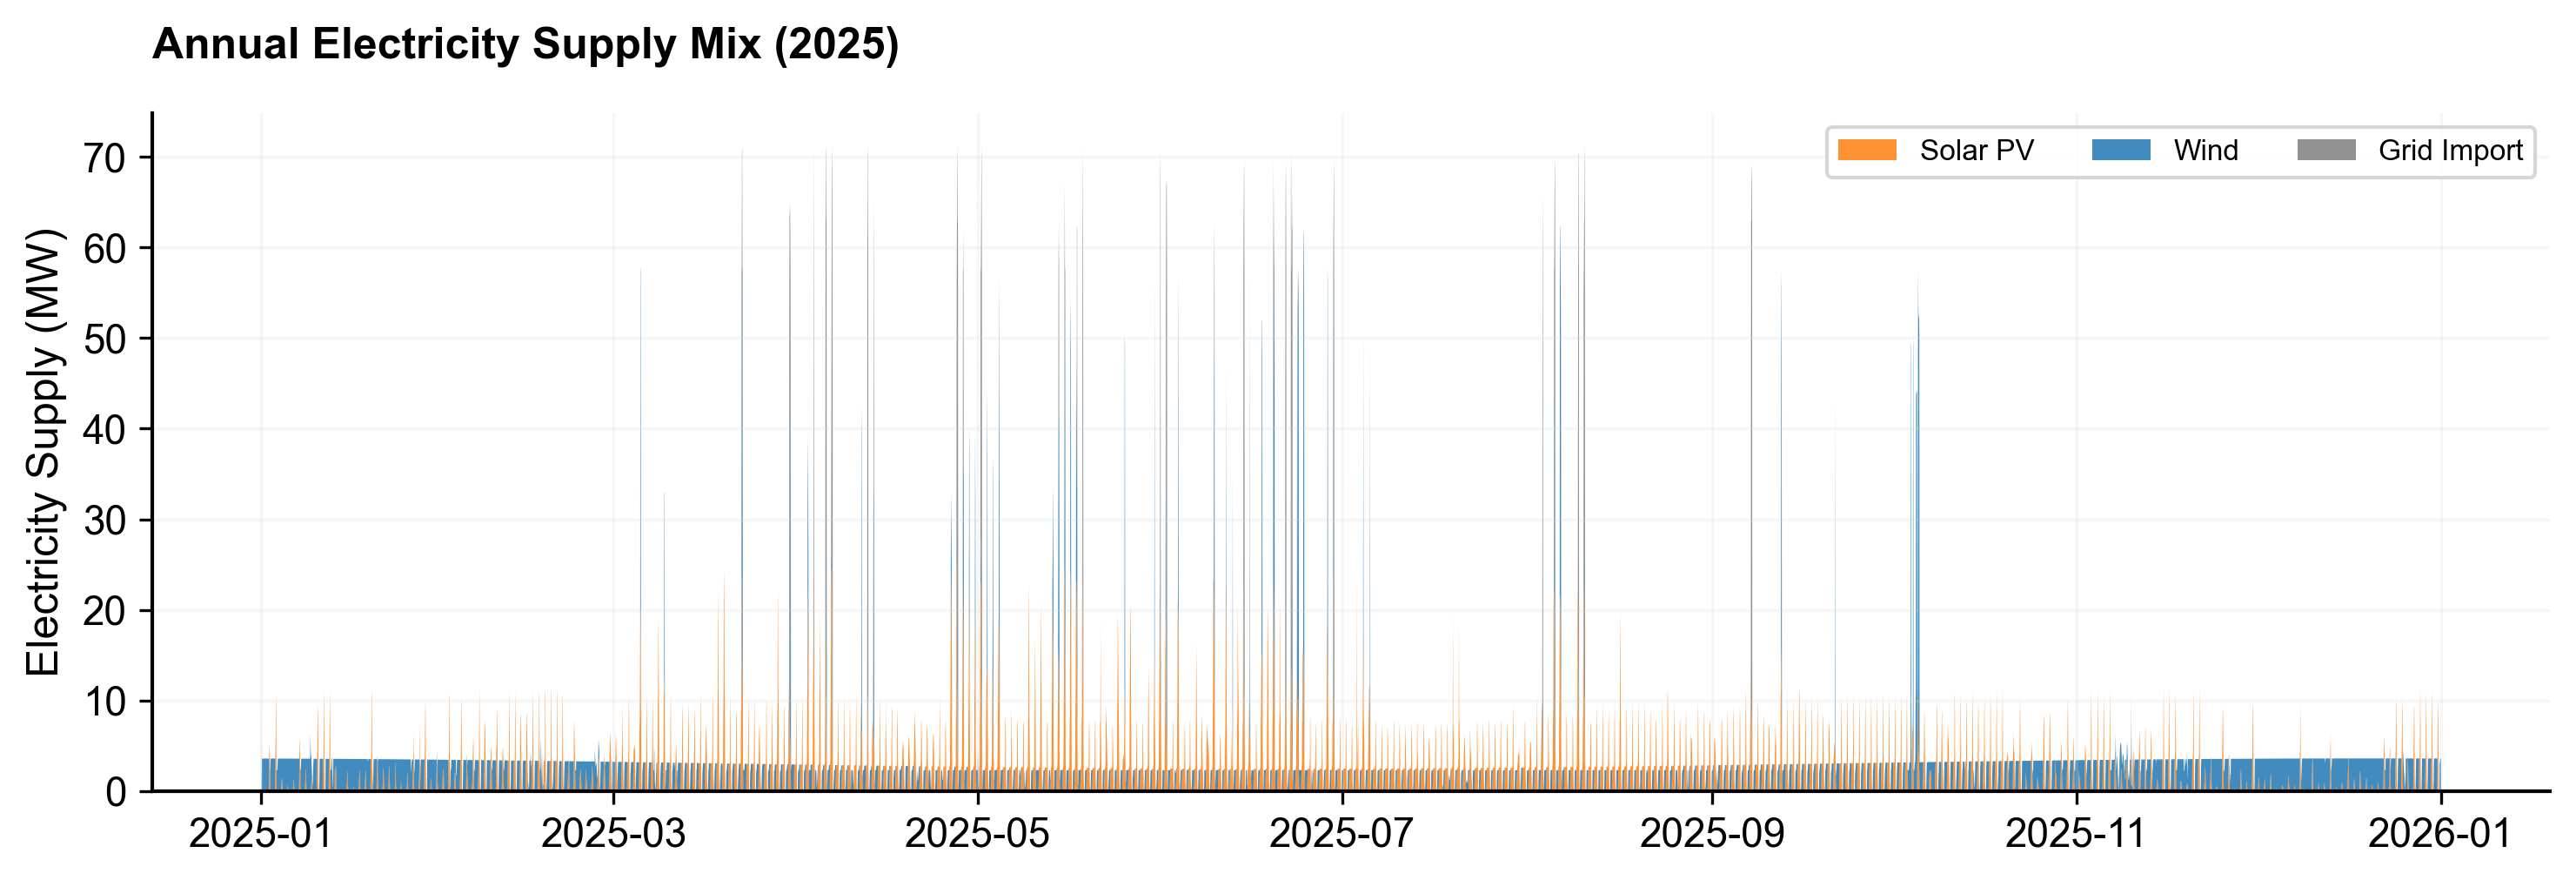

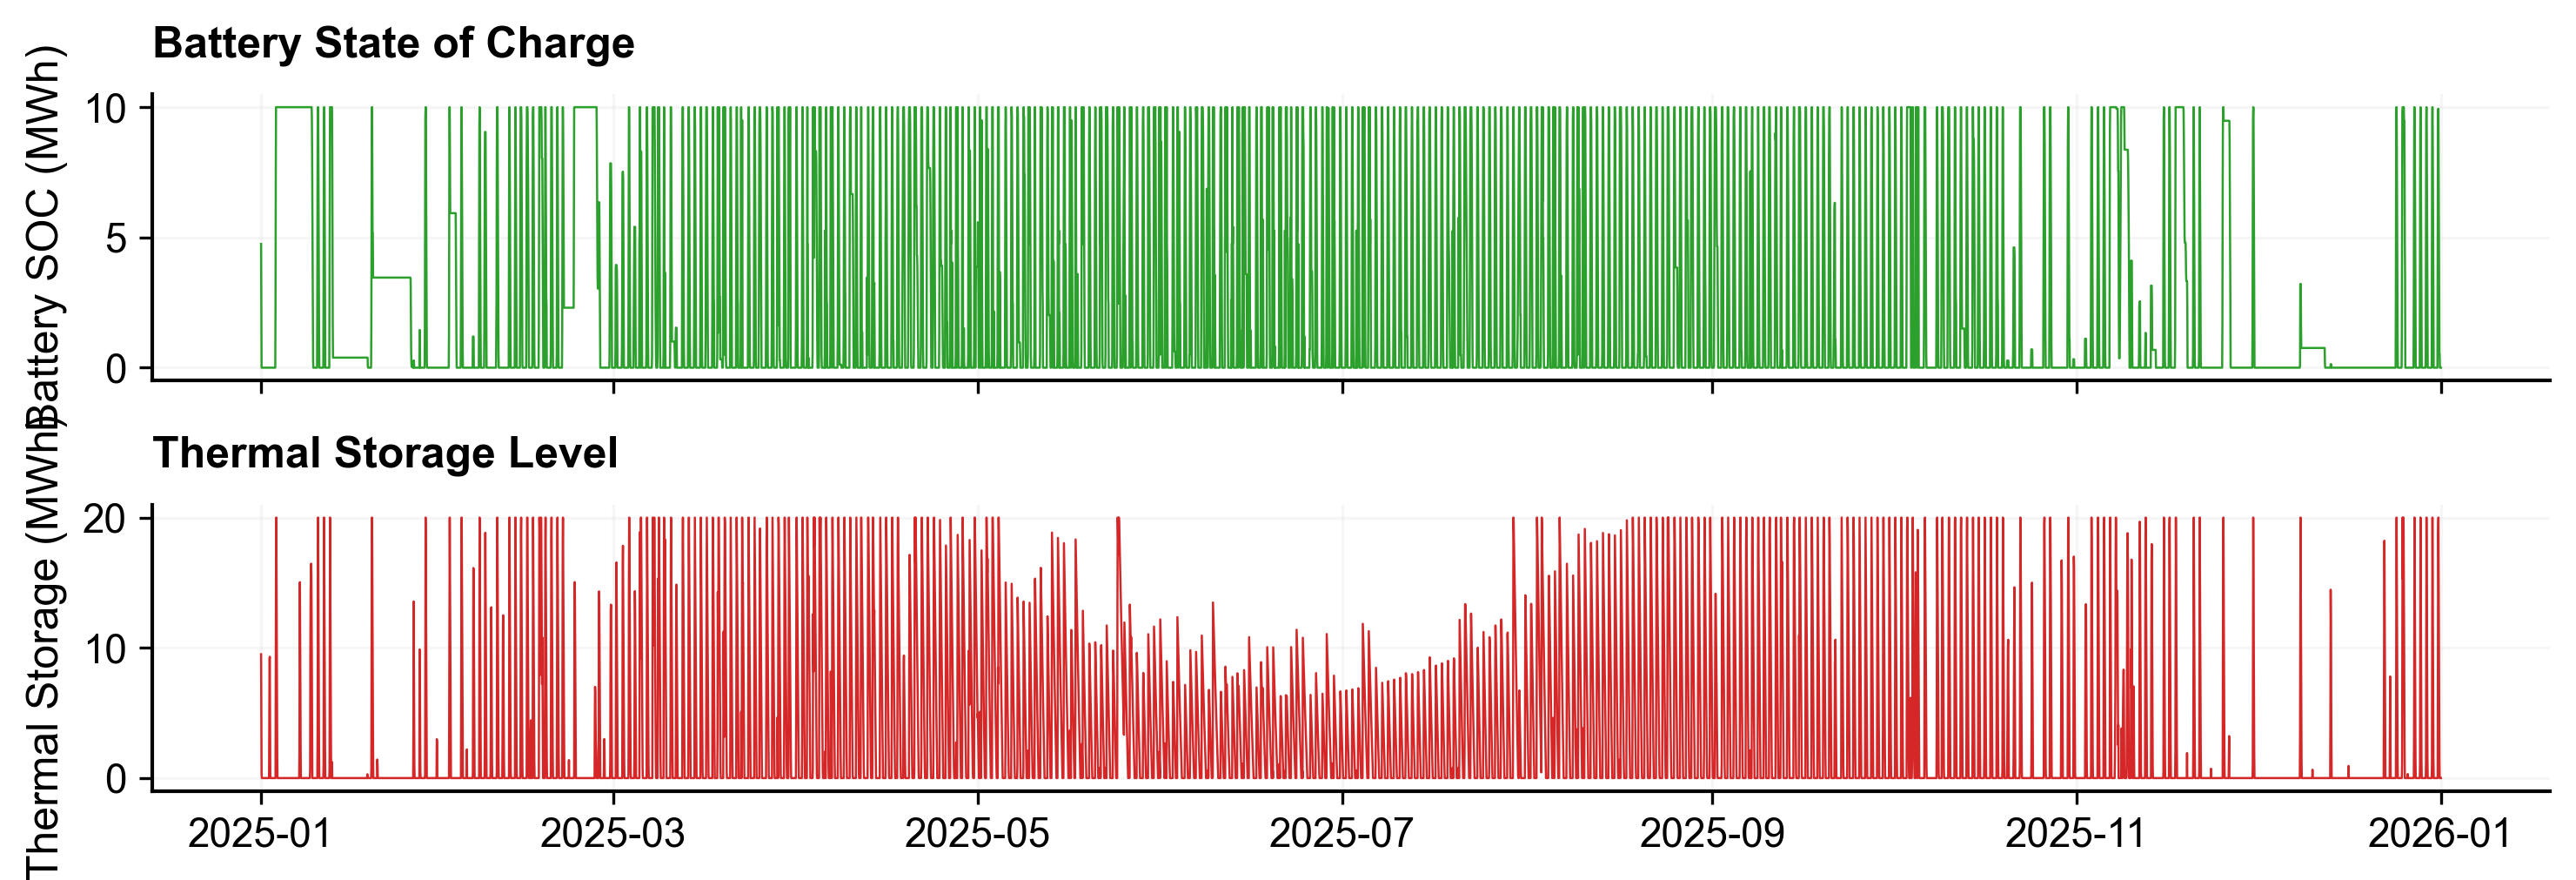

In [30]:
# --- Energy totals ---
solar_gen = n.generators_t.p['Solar_PV'].sum()
wind_gen = n.generators_t.p['Wind'].sum()
grid_import = n.generators_t.p['Grid_Import'].sum()
grid_export = -n.generators_t.p['Grid_Export'].sum()

h2_produced_mwh = -n.links_t.p1['Electrolyzer'].sum()
h2_produced_kg = h2_produced_mwh * 1000 / prices['h2_lhv_kwh_per_kg']
heat_from_electrolyzer = -n.links_t.p2['Electrolyzer'].sum()
heat_from_hp = -n.links_t.p1['Heat_Pump'].sum()
heat_sold = -n.generators_t.p['Heat_Market'].sum()

print(f"Total Solar Production:      {solar_gen:,.0f} MWh")
print(f"Total Wind Production:       {wind_gen:,.0f} MWh")
print(f"Total Grid Import:           {grid_import:,.0f} MWh")
print(f"Total Grid Export:           {grid_export:,.0f} MWh")
print("-" * 45)
print(f"Total Hydrogen Produced:     {h2_produced_mwh:,.0f} MWh ({h2_produced_kg:,.0f} kg)")
print(f"Heat Captured (Electrolyzer):{heat_from_electrolyzer:,.0f} MWh")
print(f"Heat Produced (Heat Pump):   {heat_from_hp:,.0f} MWh")
print(f"Surplus Heat Sold to DH Grid:{heat_sold:,.0f} MWh")

# --- Plot: annual electricity dispatch mix ---
fig, ax = plt.subplots()
ax.stackplot(n.snapshots,
             n.generators_t.p['Solar_PV'].clip(lower=0),
             n.generators_t.p['Wind'].clip(lower=0),
             n.generators_t.p['Grid_Import'].clip(lower=0),
             labels=['Solar PV', 'Wind', 'Grid Import'],
             colors=['#ff7f0e', '#1f77b4', '#7f7f7f'], alpha=0.85)
ax.set_ylabel('Electricity Supply (MW)')
ax.set_title('Annual Electricity Supply Mix (2025)', pad=15, loc='left', fontweight='bold')
ax.legend(loc='upper right', ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

# --- Plot: battery and thermal storage state of charge ---
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(n.snapshots, n.storage_units_t.state_of_charge['Battery'], color='#2ca02c', linewidth=0.6)
ax1.set_ylabel('Battery SOC (MWh)')
ax1.set_title('Battery State of Charge', pad=10, loc='left', fontweight='bold')

ax2.plot(n.snapshots, n.stores_t.e['Thermal_Storage'], color='#d62728', linewidth=0.6)
ax2.set_ylabel('Thermal Storage (MWh)')
ax2.set_title('Thermal Storage Level', pad=10, loc='left', fontweight='bold')

plt.tight_layout()
plt.show()


## 💶 Economic Evaluation: LCOE and LCOH

We close with the two standard levelized-cost metrics, using the conventional formulation:

$$\text{LCOE} = \frac{\sum_t \left(\text{CAPEX}_{\text{annualized}} + \text{OPEX}_t\right)}{\sum_t E_t}$$

Applied to the whole plant, this gives the levelized cost of every MWh of electricity delivered
to the site (from solar, wind, and grid import combined), net of the revenue earned by exporting
surplus power and selling surplus heat.

For hydrogen, the standard approach is to charge the electrolyzer's own annualized CAPEX plus the
electricity it consumed (priced at the system LCOE) against the hydrogen it produced:

$$\text{LCOH} = \frac{\text{CAPEX}_{\text{electrolyzer}} + \left(E_{\text{electrolyzer}} \times \text{LCOE}\right)}{m_{\text{H}_2}}$$

where $E_{\text{electrolyzer}}$ is the electrolyzer's annual electricity input (MWh) and
$m_{\text{H}_2}$ is the annual hydrogen output (kg).


In [31]:
# --- CAPEX (annualized, from the capital_cost already embedded via annuity()) ---
capex_solar = tech_param['solar_pv']['p_nom'] * tech_param['solar_pv']['capital_cost']
capex_wind = tech_param['wind']['p_nom'] * tech_param['wind']['capital_cost']
capex_electrolyzer = tech_param['electrolyzer']['p_nom'] * tech_param['electrolyzer']['capital_cost']
capex_heat_pump = tech_param['heat_pump']['p_nom'] * tech_param['heat_pump']['capital_cost']
capex_battery = tech_param['battery']['p_nom'] * tech_param['battery']['capital_cost']
capex_thermal_storage = tech_param['thermal_storage']['e_nom'] * tech_param['thermal_storage']['capital_cost']

total_capex = (capex_solar + capex_wind + capex_electrolyzer + capex_heat_pump
               + capex_battery + capex_thermal_storage)

# --- OPEX (variable costs from dispatch) ---
opex_solar = solar_gen * tech_param['solar_pv']['marginal_cost']
opex_wind = wind_gen * tech_param['wind']['marginal_cost']
opex_grid_import = (n.generators_t.p['Grid_Import'] * (df_price['price'] + tech_param['grid_connection']['grid_tariff'])).sum()
opex_heat_pump = heat_from_hp / tech_param['heat_pump']['cop'] * tech_param['heat_pump']['marginal_cost']

total_opex = opex_solar + opex_wind + opex_grid_import + opex_heat_pump

# --- Revenues (surplus energy sold) ---
revenue_grid_export = (n.generators_t.p['Grid_Export'] * -1 * df_price['price']).sum()
revenue_heat = heat_sold * prices['dh_sale_price']
total_revenue = revenue_grid_export + revenue_heat

# --- Net annual system cost, and total electricity delivered to the site ---
net_annual_cost = total_capex + total_opex - total_revenue
total_electricity_supplied = solar_gen + wind_gen + grid_import

lcoe = net_annual_cost / total_electricity_supplied

# --- LCOH: electrolyzer CAPEX + its electricity input priced at the system LCOE ---
electrolyzer_electricity_input = h2_produced_mwh / tech_param['electrolyzer']['efficiency_h2']
lcoh_eur_per_mwh = (capex_electrolyzer + electrolyzer_electricity_input * lcoe) / h2_produced_mwh
lcoh_eur_per_kg = lcoh_eur_per_mwh * prices['h2_lhv_kwh_per_kg'] / 1000

print("="*55)
print(" 💰 ANNUALIZED SYSTEM COST BREAKDOWN")
print("="*55)
print(f"Total CAPEX (annualized):     €{total_capex:,.0f}/year")
print(f"Total OPEX:                   €{total_opex:,.0f}/year")
print(f"Total Revenue (export+heat):  €{total_revenue:,.0f}/year")
print(f"Net Annual System Cost:       €{net_annual_cost:,.0f}/year")
print("-"*55)
print(f"LCOE:  €{lcoe:,.2f} / MWh")
print(f"LCOH:  €{lcoh_eur_per_mwh:,.2f} / MWh  (€{lcoh_eur_per_kg:,.2f} / kg H2)")
print("="*55)


 💰 ANNUALIZED SYSTEM COST BREAKDOWN
Total CAPEX (annualized):     €7,221,181/year
Total OPEX:                   €11,781/year
Total Revenue (export+heat):  €-89,065/year
Net Annual System Cost:       €7,322,026/year
-------------------------------------------------------
LCOE:  €180.36 / MWh
LCOH:  €316.37 / MWh  (€10.54 / kg H2)
